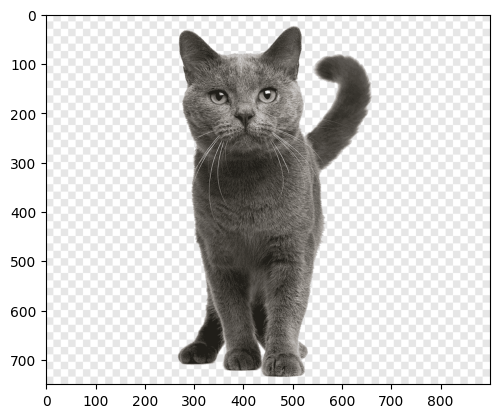

In [1]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

obrazek = input()

img = mpimg.imread(f"{obrazek}.png")
oryginal = img
plt.imshow(img)
plt.show()

# print(img.shape)

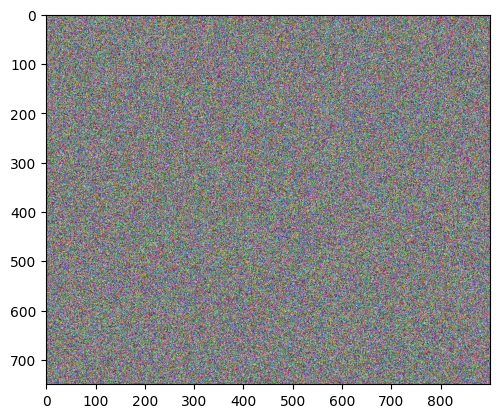

In [2]:
szum = np.zeros((img.shape[0], img.shape[1], img.shape[2]))
for i in range(szum.shape[0]):
    for j in range(szum.shape[1]):
        szum[i, j] = np.random.random(img.shape[2])
        if img.shape[2] == 4:
            szum[i, j, 3] = 1.0
        
plt.imshow(szum)
plt.show()

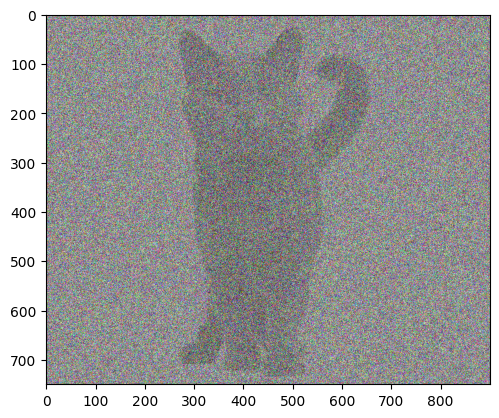

In [3]:
img = oryginal.copy()

def zaszumienie1(img, szum, moc):
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            img[i, j] = (img[i, j] + moc * szum[i, j]) / (moc + 1.0)
    
zaszumienie1(img, szum, 6.5)
plt.imshow(img)
plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.098038755..1.0000005].


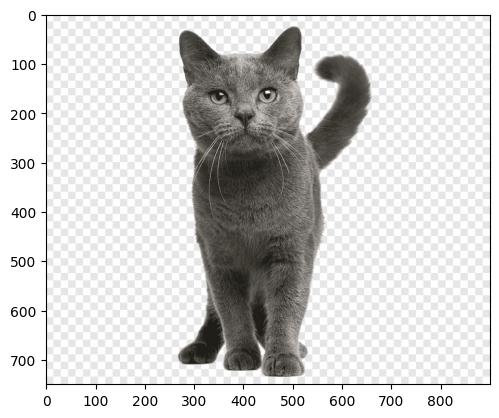

In [4]:
def odszumienie1(img, szum, moc):
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            img[i, j] *= (moc + 1.0)
            img[i, j] -= moc * szum[i, j]

odszumienie1(img, szum, 6.5)
plt.imshow(img)
plt.show()

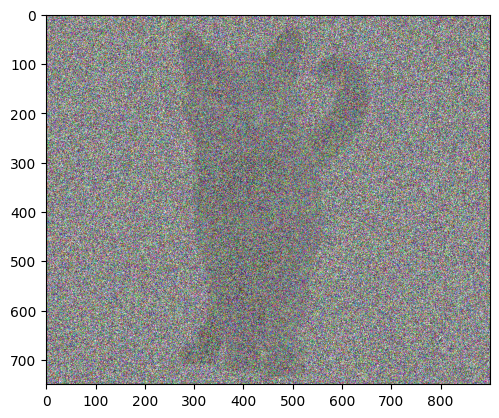

In [5]:
img = oryginal.copy()

def zaszumienie2(img, szum, moc):
    where = []
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            x = np.random.random(1)
            if x < moc:
                where.append((i, j, img[i, j].copy()))
                img[i, j] = szum[i, j]
    
    return where

where = zaszumienie2(img, szum, 0.90)
plt.imshow(img)
plt.show()

607067


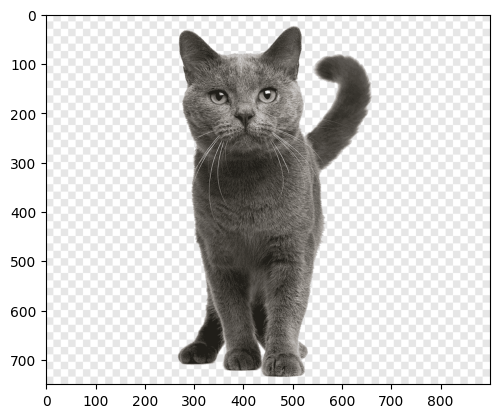

In [6]:
def odszumienie2(img, where):
    print(len(where))
    for i, j, val in where:
        img[i, j] = val
    
odszumienie2(img, where)
plt.imshow(img)
plt.show()